<a href="https://colab.research.google.com/github/ajrotech/NCAI_Internship-/blob/main/train_license_plate_yolov8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# License Plate Detection — YOLOv8 Training (corrected)

This notebook trains a YOLOv8 model to detect license plates on your Kaggle dataset.


1. **`val` pointed at the same folder as `train`.** Checked against the dataset's *own* original `dataset.yaml` (recovered from the partial download you started), the intended layout is a separate `images/val`. Validating on the training set always looks better than it should, because the model has already memorized those images — so the "accuracy" it reports can't be trusted. This notebook checks for a real `images/val` and, if it's missing or empty, builds one automatically from a held-out slice of `train`, so the mAP you see later in this notebook is trustworthy.
2. **Default model swapped from `yolov8n` (nano) to `yolov8s` (small).** Nano is the fastest/lightest YOLOv8 variant but also the least accurate. For a single small-object class like a plate, the accuracy gained going `n -> s` is usually worth the modest speed cost on a free Colab GPU. Switch back to `n` below if you need speed more than accuracy.
3. **Slight rotation augmentation added** (`degrees=8`) since plates are photographed at an angle far more often than dead-on.
4. **A visual sanity check of your annotations is included *before* training.** This is the single most common reason a plate detector underperforms, and it's easy to skip — no amount of hyperparameter tuning fixes bad or misaligned labels.

Run the cells top to bottom. **Runtime → Change runtime type → GPU** first.

In [ ]:
!pip install -q ultralytics
from ultralytics import YOLO
import ultralytics
ultralytics.checks()

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 46.7/112.6 GB disk)


**Load Dataset:**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [ ]:
import zipfile

with zipfile.ZipFile("dataset.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

In [ ]:
import os

DATASET_ROOT = "/content/dataset/archive"   # <-- update if yours is elsewhere
MODEL_SIZE = "s"                             # 'n' (fastest) | 's' (recommended) | 'm' (most accurate, slowest)
IMG_SIZE = 640
EPOCHS = 100
PATIENCE = 20

IMAGES_TRAIN = os.path.join(DATASET_ROOT, "images", "train")
IMAGES_VAL = os.path.join(DATASET_ROOT, "images", "val")
LABELS_TRAIN = os.path.join(DATASET_ROOT, "labels", "train")
LABELS_VAL = os.path.join(DATASET_ROOT, "labels", "val")

for p in [IMAGES_TRAIN, LABELS_TRAIN]:
    assert os.path.isdir(p), f"Missing required folder: {p}. Update DATASET_ROOT above."

print("images/train:", len(os.listdir(IMAGES_TRAIN)), "files")
print("labels/train:", len(os.listdir(LABELS_TRAIN)), "files")
print("images/val  :", len(os.listdir(IMAGES_VAL)) if os.path.isdir(IMAGES_VAL) else "MISSING")

images/train: 1526 files
labels/train: 1526 files
images/val  : 169


**Validation of Data**

In [ ]:
import random
import shutil

random.seed(42)
VAL_FRACTION = 0.15

val_has_data = os.path.isdir(IMAGES_VAL) and len(os.listdir(IMAGES_VAL)) > 0

if val_has_data:
    print("images/val already has data - leaving it alone.")
else:
    print(f"No usable images/val found - creating one from a held-out {VAL_FRACTION:.0%} "
          "slice of train, so validation happens on data the model has never seen.")
    os.makedirs(IMAGES_VAL, exist_ok=True)
    os.makedirs(LABELS_VAL, exist_ok=True)

    all_images = sorted(
        f for f in os.listdir(IMAGES_TRAIN)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    )
    random.shuffle(all_images)
    n_val = max(1, int(len(all_images) * VAL_FRACTION))
    val_images = all_images[:n_val]

    moved, skipped = 0, 0
    for img_name in val_images:
        label_name = os.path.splitext(img_name)[0] + ".txt"
        src_img = os.path.join(IMAGES_TRAIN, img_name)
        src_lbl = os.path.join(LABELS_TRAIN, label_name)
        if not os.path.exists(src_lbl):
            skipped += 1
            continue  # don't move an image whose label we can't find
        shutil.move(src_img, os.path.join(IMAGES_VAL, img_name))
        shutil.move(src_lbl, os.path.join(LABELS_VAL, label_name))
        moved += 1

    print(f"Moved {moved} image/label pairs into images/val and labels/val.")
    if skipped:
        print(f"WARNING: skipped {skipped} images with no matching .txt label - "
              "check that your images/ and labels/ filenames line up 1:1.")

print("Final counts - train:", len(os.listdir(IMAGES_TRAIN)), "| val:", len(os.listdir(IMAGES_VAL)))

images/val already has data - leaving it alone.
Final counts - train: 1526 | val: 169


In [ ]:
import yaml

data_yaml_path = os.path.join(DATASET_ROOT, "data.yaml")
data_yaml = {
    "path": DATASET_ROOT,
    "train": "images/train",
    "val": "images/val",   # <-- this was the bug: previously pointed back at images/train
    "names": {0: "license_plate"},
}
with open(data_yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(open(data_yaml_path).read())

names:
  0: license_plate
path: /content/dataset/archive
train: images/train
val: images/val



## 2. Sanity-check the annotations before you spend GPU time training

This draws the YOLO-format boxes from a few random `labels/train/*.txt` files on top
of their images. If the boxes are missing, offset, or clearly not around a plate, fix
the dataset before training - tuning hyperparameters can't fix bad labels.

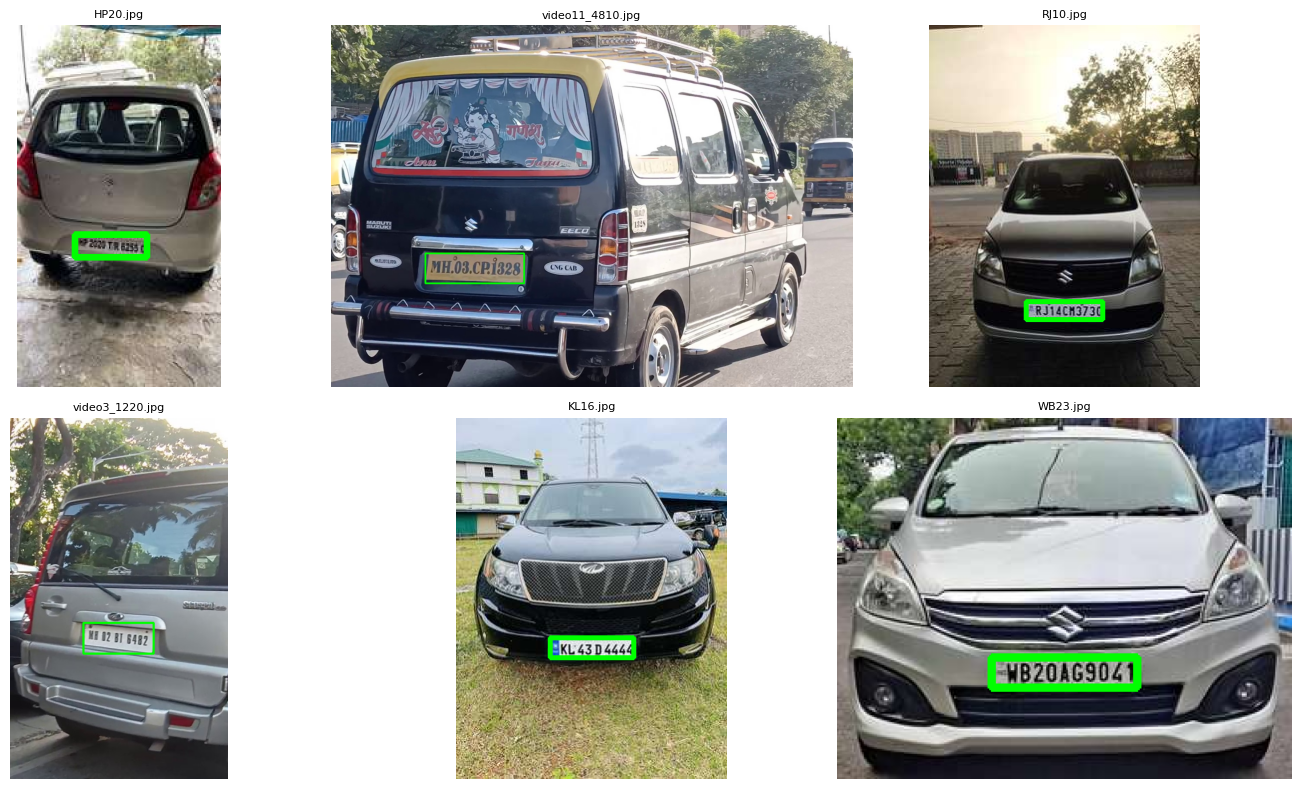

In [ ]:
import cv2
import matplotlib.pyplot as plt


def draw_yolo_labels(image_path, label_path):
    img = cv2.imread(image_path)
    h, w = img.shape[:2]
    has_label = os.path.exists(label_path)
    if has_label:
        with open(label_path) as f:
            for line in f:
                parts = line.split()
                if len(parts) < 5:
                    continue
                cls, xc, yc, bw, bh = map(float, parts[:5])
                x1 = int((xc - bw / 2) * w)
                y1 = int((yc - bh / 2) * h)
                x2 = int((xc + bw / 2) * w)
                y2 = int((yc + bh / 2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB), has_label


sample_images = random.sample(os.listdir(IMAGES_TRAIN), min(6, len(os.listdir(IMAGES_TRAIN))))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, img_name in zip(axes.flat, sample_images):
    img_path = os.path.join(IMAGES_TRAIN, img_name)
    label_path = os.path.join(LABELS_TRAIN, os.path.splitext(img_name)[0] + ".txt")
    vis, has_label = draw_yolo_labels(img_path, label_path)
    ax.imshow(vis)
    ax.set_title(img_name if has_label else f"{img_name}\n(NO LABEL FILE FOUND)", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Train

`yolov8s.pt` (or whichever `MODEL_SIZE` you set above) downloads automatically as the
starting checkpoint - that's the pretrained backbone getting fine-tuned on your plates,
not a shortcut around training.

In [ ]:
model = YOLO(f"yolov8{MODEL_SIZE}.pt")

results = model.train(
    data=data_yaml_path,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    patience=PATIENCE,
    batch=-1,        # auto batch size based on available GPU memory
    degrees=8,        # plates are usually photographed at a slight angle, not dead-on
    project="runs",
    name="plate_detector",
    exist_ok=True,
)

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/archive/data.yaml, degrees=8, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plate_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ov

## 4. Validate on the (real, held-out) val set

In [ ]:
best_weights = "/content/runs/detect/runs/plate_detector/weights/best.pt"
best_model = YOLO(best_weights)
metrics = best_model.val(data=data_yaml_path, split="val")

print(f"mAP50:     {metrics.box.map50:.3f}")
print(f"mAP50-95:  {metrics.box.map:.3f}")
print(f"Precision: {metrics.box.mp:.3f}")
print(f"Recall:    {metrics.box.mr:.3f}")

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3278.5±1766.7 MB/s, size: 225.7 KB)
val: Scanning /content/dataset/archive/labels/val.cache... 169 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 169/169 59.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 3.1it/s 3.6s
                   all        169        169      0.992      0.994      0.994       0.84
Speed: 3.1ms preprocess, 8.4ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /content/runs/detect/val
mAP50:     0.994
mAP50-95:  0.840
Precision: 0.992
Recall:    0.994


## 5. Preview predictions on a few val images


0: 640x640 1 license_plate, 13.3ms
1: 640x640 1 license_plate, 13.3ms
2: 640x640 2 license_plates, 13.3ms
3: 640x640 1 license_plate, 13.3ms
4: 640x640 1 license_plate, 13.3ms
5: 640x640 1 license_plate, 13.3ms
Speed: 3.2ms preprocess, 13.3ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


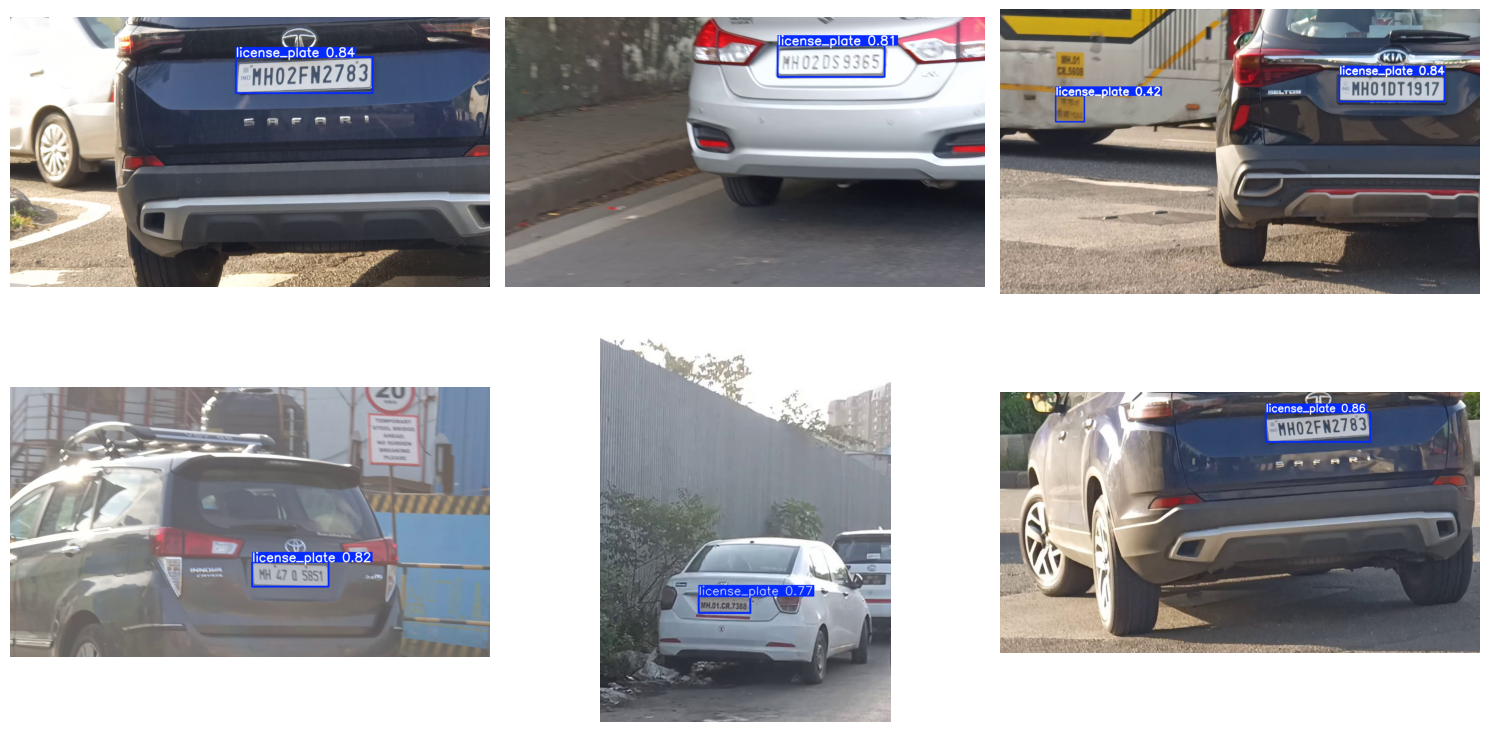

In [ ]:
val_files = os.listdir(IMAGES_VAL)
val_samples = random.sample(val_files, min(6, len(val_files)))
pred_results = best_model.predict(
    source=[os.path.join(IMAGES_VAL, f) for f in val_samples],
    conf=0.4,
    save=False,
)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, r in zip(axes.flat, pred_results):
    ax.imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
    ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Download the trained weights

Grab `best.pt` and drop it next to `app.py` in the Streamlit app (or update the path
in the app's sidebar) to run the full detect-and-read pipeline on new photos.

In [ ]:
from google.colab import files

files.download(best_weights)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notes on pushing accuracy higher still

- **More/better data beats more epochs.** If mAP50 is still under ~0.85 after this run,
  the highest-leverage next step is usually more varied training images (different
  lighting, angles, distances, plate styles) rather than more epochs.
- **`MODEL_SIZE = "m"`** if you have GPU budget left - bigger backbone, better
  small-object accuracy, slower to train and to run.
- **`IMG_SIZE = 960`** if plates are small relative to the full photo (e.g. the vehicle
  is far from the camera) - YOLO resizes to this internally, and a tiny plate loses
  almost all its detail at 640.
- Check `runs/plate_detector/` for training curves (`results.png`) and a confusion
  matrix before deciding the model is "done" - `results.png` in particular shows
  whether loss was still improving when training stopped.